# Financial Forecasting and Credit Risk Modeling
End-to-end notebook workflow aligned with the project README: ETL feature engineering, imbalance-aware credit risk modeling, customer scoring, ARIMA forecasting, and business impact analysis.

In [9]:
import os
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc,
    mean_absolute_error,
    mean_absolute_percentage_error,
    )
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
os.makedirs("images", exist_ok=True)
os.makedirs("models", exist_ok=True)

sys.path.insert(0, "scripts")
from etl_pipeline import run_etl

In [ ]:
# Load raw dataset for quick EDA
df_raw = pd.read_csv("data/synthetic_transactions.csv", parse_dates=["Date"])
print(f"Rows: {len(df_raw):,}")
print(f"Customers: {df_raw['CustomerID'].nunique():,}")
print(f"Date range: {df_raw['Date'].min().date()} to {df_raw['Date'].max().date()}")
print(f"Default rate: {df_raw['Defaulted'].mean():.2%}")

df_raw.head()

,TransactionID,CustomerID,Date,Amount,PaymentType,CreditScore,Defaulted
0,3d6b0919-4fdc-08b2-9dc2-5adb1070f0a8,fd50c123-95fd-2c09-fd4f-22f078c8b3f5,2022-01-01,287.64,Credit Card,651,0
1,a3c7c018-77dc-25c7-bbc1-1fddaa779c58,5e3005fe-704d-f463-b00c-361db86af57b,2022-01-01,101.10,PayPal,757,0
2,bba80b74-36e1-c97e-4b4c-0e2f93689e3f,91e49885-24a4-08b6-0d08-ac9a31c00181,2022-01-01,272.95,Credit Card,727,0
3,8ac0c857-035a-383f-175b-43c2111ff9b1,132eb790-dc8b-8955-1ebd-d07c2c5d492c,2022-01-01,445.05,Wire Transfer,673,0
4,16dd3ccd-eb5e-ee3a-c628-a0fce4faf6af,383aab90-d172-8027-5294-9e9199178aee,2022-01-01,137.32,PayPal,548,0


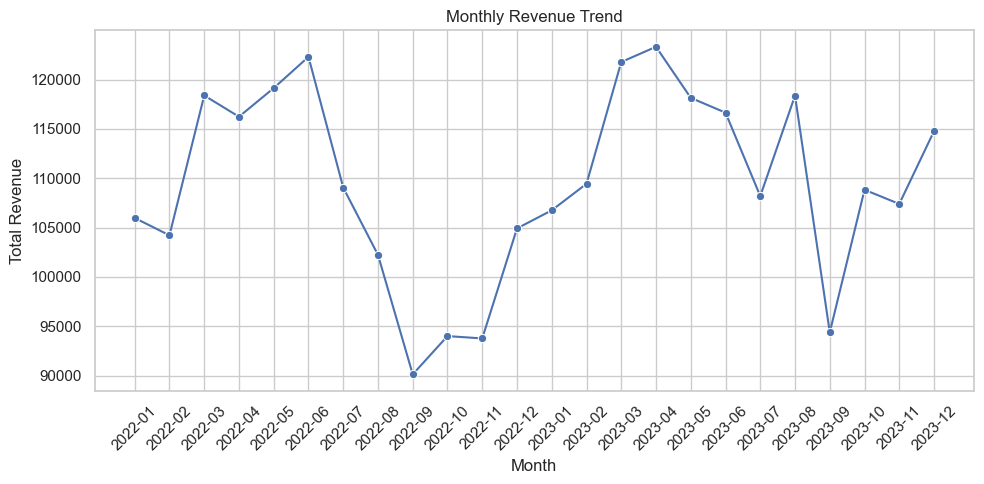

In [ ]:
# Feature engineering via ETL pipeline (README-aligned)
df = run_etl("data/synthetic_transactions.csv")

FEATURE_COLS = [
    "Amount",
    "AmountLog",
    "CreditScore",
    "IsHighValue",
    "DayOfWeek",
    "PaymentType_Debit Card",
    "PaymentType_PayPal",
    "PaymentType_Wire Transfer",
]
TARGET_COL = "Defaulted"

for col in FEATURE_COLS:
    if col not in df.columns:
        df[col] = 0

print(f"ETL output shape: {df.shape}")
df[FEATURE_COLS + [TARGET_COL]].head()

In [ ]:
# Train/test split
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train default rate:", f"{y_train.mean():.2%}")

In [ ]:
# Model benchmark: Logistic Regression, Random Forest, XGBoost
pipelines = {
    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(n_estimators=350, max_depth=10, random_state=42, n_jobs=-1)),
    ]),
    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        (
            "clf",
            XGBClassifier(
                n_estimators=400,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=42,
                verbosity=0,
            ),
        ),
    ]),
}

cv_splitter = StratifiedKFold(5, shuffle=True, random_state=42)
results = []

for name, model in pipelines.items():
    print(f"\nTraining {name}...")
    cv = cross_val_score(model, X_train, y_train, scoring="roc_auc", cv=cv_splitter, n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print(f"CV ROC-AUC: {cv.mean():.4f} +/- {cv.std():.4f}")
    print(f"Test ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

    results.append({
        "Model": name,
        "CV_ROC_AUC_MEAN": cv.mean(),
        "CV_ROC_AUC_STD": cv.std(),
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "roc": (fpr, tpr),
        "pr": (recall, precision),
        "cm": cm,
    })

report_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "CV_ROC_AUC_MEAN": round(r["CV_ROC_AUC_MEAN"], 4),
        "CV_ROC_AUC_STD": round(r["CV_ROC_AUC_STD"], 4),
        "ROC_AUC": round(r["ROC_AUC"], 4),
        "PR_AUC": round(r["PR_AUC"], 4),
    }
    for r in results
])
report_df = report_df.sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
best = max(results, key=lambda r: r["ROC_AUC"])

report_df.to_csv("credit_risk_model_report.csv", index=False)
joblib.dump(best["model"], "models/credit_risk_model.pkl")

print("\nBest model:", best["Model"], f"(ROC-AUC={best['ROC_AUC']:.4f})")
report_df

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1941
           1       0.50      0.02      0.03        59

    accuracy                           0.97      2000
   macro avg       0.74      0.51      0.51      2000
weighted avg       0.96      0.97      0.96      2000



In [ ]:
# Evaluation visuals: confusion matrices + ROC/PR curves
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    sns.heatmap(
        r["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Default", "Default"],
        yticklabels=["No Default", "Default"],
        ax=ax,
    )
    ax.set_title(r["Model"]); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("images/confusion_matrices.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax_roc, ax_pr = axes
ax_roc.plot([0, 1], [0, 1], "--", color="gray", label="No-skill")
ax_pr.hlines(y_test.mean(), 0, 1, linestyles="--", colors="gray", label="No-skill")

for r in results:
    fpr, tpr = r["roc"]
    recall, precision = r["pr"]
    ax_roc.plot(fpr, tpr, label=f"{r['Model']} (AUC={r['ROC_AUC']:.3f})")
    ax_pr.plot(recall, precision, label=f"{r['Model']} (AP={r['PR_AUC']:.3f})")

ax_roc.set_title("ROC Curves"); ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR"); ax_roc.legend(loc="lower right")
ax_pr.set_title("Precision-Recall Curves"); ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision"); ax_pr.legend(loc="upper right")

plt.tight_layout()
plt.savefig("images/roc_pr_curves.png", dpi=150)
plt.show()

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1941
           1       0.25      0.02      0.03        59

    accuracy                           0.97      2000
   macro avg       0.61      0.51      0.51      2000
weighted avg       0.95      0.97      0.96      2000



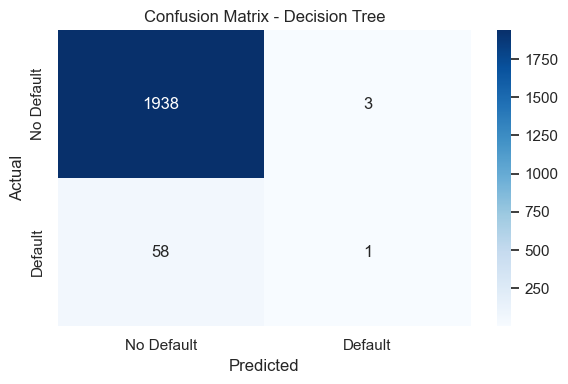

In [ ]:
# Revenue forecasting with ARIMA (README-aligned)
monthly_revenue = (
    df_raw.groupby(df_raw["Date"].dt.to_period("M"))["Amount"]
    .sum()
    .to_timestamp()
    .rename("Revenue")
)

pvalue = adfuller(monthly_revenue.dropna())[1]
d = 0 if pvalue < 0.05 else 1
print(f"ADF p-value: {pvalue:.4f}; using d={d}")

best_order = (1, d, 1)
best_aic = np.inf
for p in range(4):
    for q in range(4):
        try:
            m = ARIMA(monthly_revenue, order=(p, d, q)).fit()
            if m.aic < best_aic:
                best_aic = m.aic
                best_order = (p, d, q)
        except Exception:
            pass

holdout = min(6, max(3, len(monthly_revenue) // 4))
train, test = monthly_revenue.iloc[:-holdout], monthly_revenue.iloc[-holdout:]
holdout_model = ARIMA(train, order=best_order).fit()
holdout_pred = holdout_model.forecast(steps=holdout)
holdout_pred.index = test.index

mae = mean_absolute_error(test.values, holdout_pred.values)
safe_den = np.where(test.values == 0, 1.0, test.values)
mape = np.mean(np.abs((test.values - holdout_pred.values) / safe_den)) * 100
print(f"Selected ARIMA{best_order} | Holdout MAE=${mae:,.2f} | MAPE={mape:.2f}%")

final_model = ARIMA(monthly_revenue, order=best_order).fit()
horizon = 6
forecast_obj = final_model.get_forecast(steps=horizon)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int(alpha=0.05)
future_idx = pd.date_range(start=monthly_revenue.index[-1] + pd.DateOffset(months=1), periods=horizon, freq="MS")
forecast_mean.index = future_idx
forecast_ci.index = future_idx

forecast_df = pd.DataFrame({
    "Month": future_idx.strftime("%b %Y"),
    "Forecast": forecast_mean.round(2).values,
    "Lower95": forecast_ci.iloc[:, 0].round(2).values,
    "Upper95": forecast_ci.iloc[:, 1].round(2).values,
})
forecast_df.to_csv("revenue_forecast.csv", index=False)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", label="Historical")
plt.plot(forecast_mean.index, forecast_mean.values, marker="D", label="Forecast")
plt.fill_between(forecast_mean.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], alpha=0.2, label="95% CI")
plt.axvline(forecast_mean.index[0], linestyle="--", color="gray", alpha=0.7)
plt.title(f"Monthly Revenue Forecast - ARIMA{best_order}")
plt.xlabel("Month"); plt.ylabel("Revenue"); plt.legend()
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig("images/revenue_forecast_arima.png", dpi=150)
plt.show()

forecast_df

## Customer Risk Scoring and Portfolio Summary
Use the saved best model to score each transaction, aggregate to customer-level risk tiers, and export summary files for monitoring and expected credit loss reporting.

In [ ]:
LGD = 0.45
scoring_df = df.copy()
best_model = best["model"]
scoring_df["default_probability"] = best_model.predict_proba(scoring_df[FEATURE_COLS])[:, 1]

def assign_tier(prob):
    if prob < 0.10:
        return "Low Risk"
    if prob < 0.25:
        return "Medium Risk"
    if prob < 0.50:
        return "High Risk"
    return "Very High Risk"

customer_scores = scoring_df.groupby("CustomerID").agg(
    transaction_count=("Amount", "count"),
    total_exposure=("Amount", "sum"),
    avg_credit_score=("CreditScore", "mean"),
    avg_default_prob=("default_probability", "mean"),
    max_default_prob=("default_probability", "max"),
    actual_defaults=("Defaulted", "sum"),
).reset_index()

customer_scores["risk_tier"] = customer_scores["max_default_prob"].apply(assign_tier)
tier_order = ["Low Risk", "Medium Risk", "High Risk", "Very High Risk"]
customer_scores["risk_tier"] = pd.Categorical(customer_scores["risk_tier"], categories=tier_order, ordered=True)
customer_scores["expected_loss"] = (customer_scores["avg_default_prob"] * customer_scores["total_exposure"] * LGD).round(2)

portfolio_summary = customer_scores.groupby("risk_tier", observed=False).agg(
    customer_count=("CustomerID", "count"),
    total_exposure=("total_exposure", "sum"),
    avg_default_prob=("avg_default_prob", "mean"),
    total_expected_loss=("expected_loss", "sum"),
).reset_index().sort_values("risk_tier")

customer_scores.to_csv("customer_risk_scores.csv", index=False)
portfolio_summary.to_csv("portfolio_risk_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=portfolio_summary, x="risk_tier", y="customer_count", color="#4c78a8", ax=axes[0])
axes[0].set_title("Customers by Risk Tier"); axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=portfolio_summary, x="risk_tier", y="total_expected_loss", color="#f58518", ax=axes[1])
axes[1].set_title("Expected Credit Loss by Tier"); axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Portfolio Risk Dashboard")
plt.tight_layout()
plt.savefig("images/portfolio_risk_dashboard.png", dpi=150)
plt.show()

portfolio_summary

## Business Impact Analysis
This section quantifies the estimated financial benefit of using the best model versus a naive baseline that misses all defaults.

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, best["y_pred"]).ravel()

avg_exposure = float(df_raw["Amount"].mean())
lgd = 0.45
review_cost_rate = 0.03

naive_cost = int(y_test.sum()) * (lgd * avg_exposure)
model_cost = fn * (lgd * avg_exposure) + fp * (review_cost_rate * avg_exposure)
savings = naive_cost - model_cost

impact_df = pd.DataFrame({
    "Scenario": ["Naive Baseline", "Model Residual Cost", "Estimated Savings"],
    "USD": [naive_cost, model_cost, savings],
})

plt.figure(figsize=(8, 4))
sns.barplot(data=impact_df, x="Scenario", y="USD", palette=["#d62728", "#ff7f0e", "#2ca02c"] )
plt.title("Business Impact Snapshot")
plt.ylabel("USD")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("images/business_impact.png", dpi=150)
plt.show()

print("Business Impact Summary")
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Naive baseline cost: ${naive_cost:,.2f}")
print(f"Model residual cost: ${model_cost:,.2f}")
print(f"Estimated savings: ${savings:,.2f}")

impact_df

NameError: name 'df_raw' is not defined